#Observing how diffusion changes mean and covariance

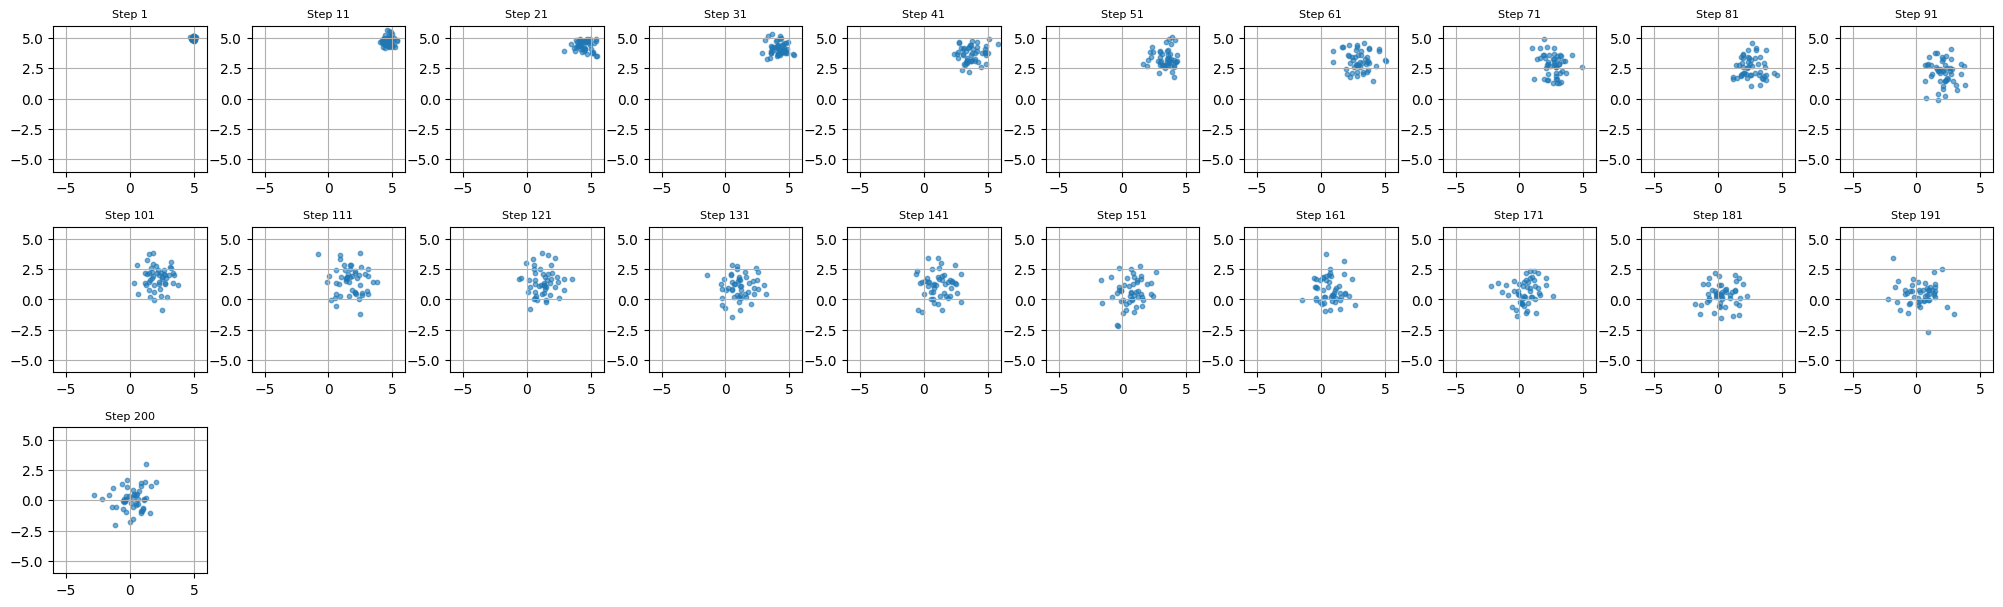

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
T = 200  # number of diffusion steps
beta = np.linspace(0.01, 0.05, T)  # noise schedule

# Original 2D vector (mean of 2D distribution)
x0 = np.array([5.0, 5.0])

# Forward diffusion simulation
alpha = 1 - beta
alpha_bar = np.cumprod(alpha)

# For plotting, generate multiple samples at each step
n_samples = 50

# Steps to plot: step 0, every 10 steps, and final step T-1 (index 199)
plot_steps = list(range(0, T, 10))
if T-1 not in plot_steps:
    plot_steps.append(T-1)

plt.figure(figsize=(20, 20))

for idx, t in enumerate(plot_steps):
    # Mean of the distribution at step t
    mean_t = np.sqrt(alpha_bar[t]) * x0

    # Covariance at step t
    cov_t = (1 - alpha_bar[t]) * np.eye(2)

    # Generate samples from N(mean, cov)
    samples = np.random.multivariate_normal(mean_t, cov_t, size=n_samples)

    # Determine limits to cover almost all points
    limit = 6  # max absolute value you want to show

    plt.subplot(10, 10, idx+1)
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.6, s=10)
    plt.xlim(-limit, limit)
    plt.ylim(-limit, limit)
    plt.title(f"Step {t+1}", fontsize=8)
    plt.grid(True)

plt.tight_layout()
plt.show()

Epoch 20/100, Loss: 0.0009
Epoch 40/100, Loss: 0.0011
Epoch 60/100, Loss: 0.0001
Epoch 80/100, Loss: 0.0001
Epoch 100/100, Loss: 0.0002


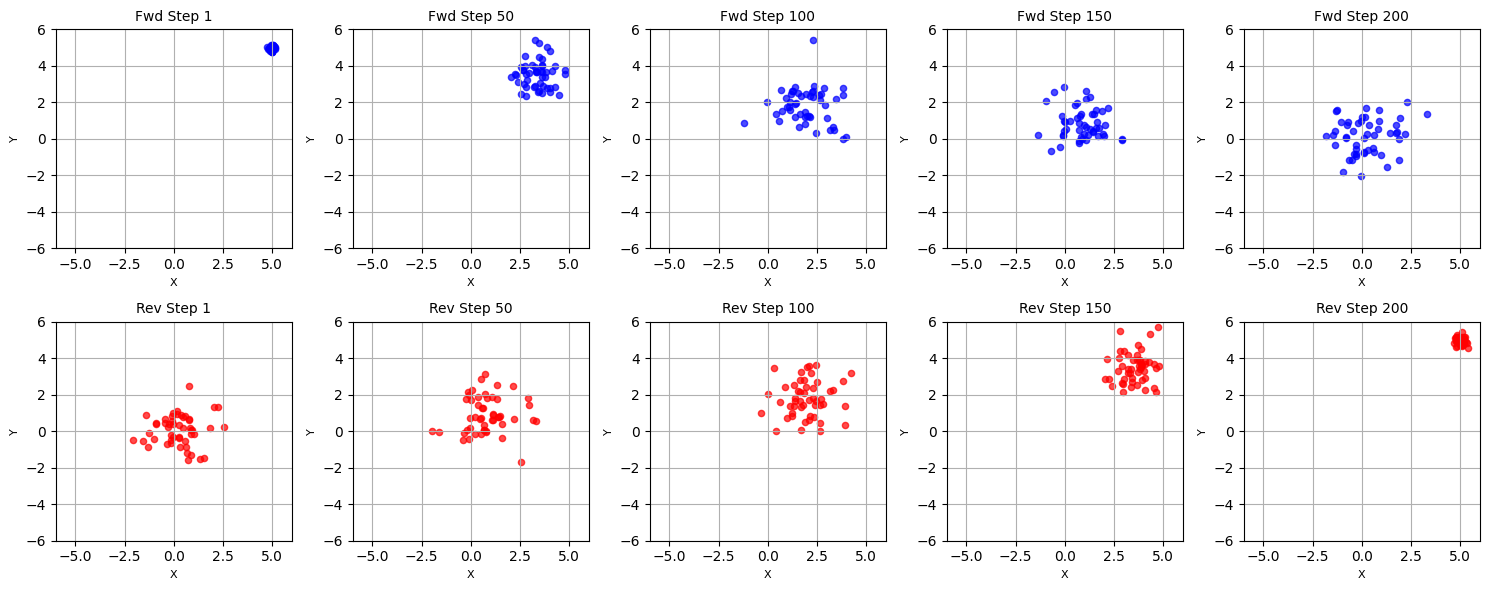

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Parameters
T = 200  # number of diffusion steps
beta = np.linspace(0.01, 0.05, T)  # noise schedule
alpha = 1 - beta
alpha_bar = np.cumprod(alpha)
x0 = np.array([5.0, 5.0])  # original mean
n_samples = 50
plot_steps = [1, 50, 100, 150, 200]  # 1-based steps for plotting

# Forward diffusion simulation
def forward_diffusion():
    samples_at_steps = []
    for t in plot_steps:
        t_idx = t - 1  # Convert to 0-based index for alpha_bar
        mean_t = np.sqrt(alpha_bar[t_idx]) * x0
        cov_t = (1 - alpha_bar[t_idx]) * np.eye(2)
        samples = np.random.multivariate_normal(mean_t, cov_t, size=n_samples)
        samples_at_steps.append(samples)
    return samples_at_steps

# Time embedding function
def get_time_embedding(t, dim=16):
    if isinstance(t, (int, float)):
        t = torch.tensor([t], dtype=torch.float)
    elif isinstance(t, torch.Tensor) and t.dim() == 0:
        t = t.unsqueeze(0)
    elif isinstance(t, torch.Tensor) and t.dim() == 1:
        pass  # Already correctly shaped
    else:
        raise ValueError("t must be a scalar or 1D tensor")

    t = t / T  # Normalize t to [0, 1]
    half_dim = dim // 2
    emb = torch.exp(-torch.arange(half_dim, dtype=torch.float, device=t.device) * np.log(10000) / half_dim)
    emb = t[:, None] * emb[None, :]
    emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=1)
    return emb  # Shape: (batch_size, dim)

# Neural network for reverse process
class ReverseDiffusionNet(nn.Module):
    def __init__(self, time_dim=16):
        super(ReverseDiffusionNet, self).__init__()
        self.time_embed = nn.Linear(time_dim, 64)
        self.input_layer = nn.Linear(2, 64)
        self.network = nn.Sequential(
            nn.Linear(128, 64),  # Combine input and time embedding
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 4)  # 2 for mean, 2 for diagonal covariance
        )

    def forward(self, x, t):
        t_embed = self.time_embed(get_time_embedding(t))  # Shape: (batch_size, 64)
        x_embed = self.input_layer(x)  # Shape: (batch_size, 64)
        combined = torch.cat((x_embed, t_embed), dim=1)  # Shape: (batch_size, 128)
        output = self.network(combined)
        mean = output[:, :2]
        cov_diag = torch.exp(output[:, 2:])  # Ensure positive covariance
        return mean, cov_diag

# Generate training data for all timesteps
def generate_training_data(n_train_samples=10000):
    noisy_samples = []
    target_means = []
    target_cov_diags = []
    timesteps = []

    for _ in range(n_train_samples):
        t = np.random.randint(1, T+1)  # Timesteps 1 to 200
        t_idx = t - 1  # Convert to 0-based for alpha_bar
        mean_t = np.sqrt(alpha_bar[t_idx]) * x0
        cov_t = (1 - alpha_bar[t_idx]) * np.eye(2)
        sample = np.random.multivariate_normal(mean_t, cov_t, size=1)
        # Target is x_{t-1} (t-1 in 1-based, t-2 in 0-based)
        mean_t_minus_1 = np.sqrt(alpha_bar[t_idx-1]) * x0 if t > 1 else x0
        cov_t_minus_1 = (1 - alpha_bar[t_idx-1]) * np.eye(2) if t > 1 else np.zeros((2, 2))
        noisy_samples.append(sample[0])
        target_means.append(mean_t_minus_1)
        target_cov_diags.append(np.diag(cov_t_minus_1))
        timesteps.append(t)

    return (np.array(noisy_samples), np.array(target_means),
            np.array(target_cov_diags), np.array(timesteps))

# Train the neural network
def train_reverse_model():
    model = ReverseDiffusionNet()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    n_epochs = 100  # Kept for better convergence
    batch_size = 128

    noisy_samples, target_means, target_cov_diags, timesteps = generate_training_data()
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(noisy_samples),
        torch.FloatTensor(target_means),
        torch.FloatTensor(target_cov_diags),
        torch.FloatTensor(timesteps)
    )
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(n_epochs):
        total_loss = 0
        for batch_samples, batch_means, batch_covs, batch_ts in dataloader:
            optimizer.zero_grad()
            pred_mean, pred_cov_diag = model(batch_samples, batch_ts)
            loss_mean = criterion(pred_mean, batch_means)
            loss_cov = criterion(pred_cov_diag, batch_covs)
            loss = loss_mean + loss_cov
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(dataloader):.4f}")

    return model

# Sample reverse process with intermediate steps
def sample_reverse(model, n_samples=50):
    model.eval()
    # Initialize with forward process distribution at t=T (200)
    mean_t = np.sqrt(alpha_bar[T-1]) * x0
    cov_t = (1 - alpha_bar[T-1]) * np.eye(2)
    samples = np.random.multivariate_normal(mean_t, cov_t, size=n_samples)
    samples = torch.FloatTensor(samples)
    reverse_samples_at_steps = []

    # Store samples at specific timesteps (matching plot_steps)
    save_steps = [T - (t-1) for t in plot_steps]  # e.g., 200, 151, 101, 51, 1

    for t in range(T, 0, -1):  # 1-based: 200 down to 1
        t_tensor = torch.full((n_samples,), t, dtype=torch.float)
        with torch.no_grad():
            mean, cov_diag = model(samples, t_tensor)
        cov = np.zeros((n_samples, 2, 2))
        cov[:, range(2), range(2)] = cov_diag.numpy()
        samples = np.array([np.random.multivariate_normal(mean[i].numpy(), cov[i]) for i in range(n_samples)])
        samples = torch.FloatTensor(samples)

        # Save samples at specified timesteps
        if t in save_steps:
            reverse_samples_at_steps.append(samples.numpy())

    return reverse_samples_at_steps  # List of samples at t=200, 151, 101, 51, 1

# Plot forward and reverse processes
def plot_results(forward_samples, reverse_samples):
    plt.figure(figsize=(15, 6))  # Smaller figure size for fewer subplots

    # Plot forward process (top row)
    for idx, t in enumerate(plot_steps):
        samples = forward_samples[idx]
        plt.subplot(2, len(plot_steps), idx+1)
        plt.scatter(samples[:, 0], samples[:, 1], alpha=0.7, s=20, c='blue')
        plt.xlim(-6, 6)
        plt.ylim(-6, 6)
        plt.title(f"Fwd Step {t}", fontsize=10)
        plt.xlabel("X", fontsize=8)
        plt.ylabel("Y", fontsize=8)
        plt.grid(True)

    # Plot reverse process (bottom row, from high entropy to low entropy)
    for idx, t in enumerate(plot_steps):
        samples = reverse_samples[idx]  # Index matches save_steps order (200, 151, 101, 51, 1)
        plt.subplot(2, len(plot_steps), len(plot_steps)+idx+1)
        plt.scatter(samples[:, 0], samples[:, 1], alpha=0.7, s=20, c='red')
        plt.xlim(-6, 6)
        plt.ylim(-6, 6)
        plt.title(f"Rev Step {t}", fontsize=10)
        plt.xlabel("X", fontsize=8)
        plt.ylabel("Y", fontsize=8)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the simulation
if __name__ == "__main__":
    forward_samples = forward_diffusion()
    model = train_reverse_model()
    reverse_samples = sample_reverse(model)
    plot_results(forward_samples, reverse_samples)

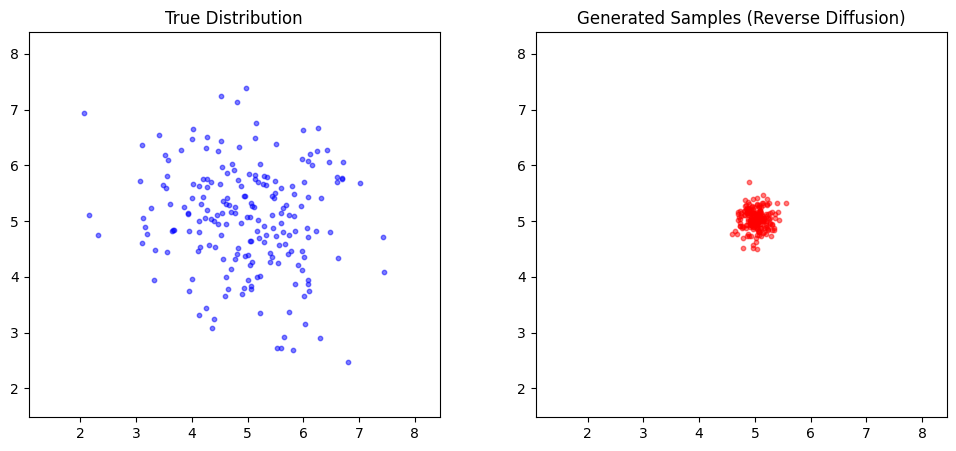

In [27]:
# Generate final samples from trained reverse model
def generate_samples(model, n_samples=2000):
    model.eval()
    # Start from isotropic Gaussian noise at T
    samples = torch.randn(n_samples, 2)  # pure noise

    for t in range(T, 0, -1):
        t_tensor = torch.full((n_samples,), t, dtype=torch.float)
        with torch.no_grad():
            mean, cov_diag = model(samples, t_tensor)
        cov = torch.zeros((n_samples, 2, 2))
        cov[:, range(2), range(2)] = cov_diag  # diag covariance
        # Sample from Gaussian N(mean, diag(cov_diag))
        eps = torch.randn_like(samples)
        samples = mean + eps * torch.sqrt(cov_diag)

    return samples.numpy()

# Example usage
gen_samples = generate_samples(model, n_samples=200)

# Plot generated vs true data with same axis scales
def plot_comparison(gen_samples, train_samples):
    x_min = min(gen_samples[:,0].min(), train_samples[:,0].min()) - 1
    x_max = max(gen_samples[:,0].max(), train_samples[:,0].max()) + 1
    y_min = min(gen_samples[:,1].min(), train_samples[:,1].min()) - 1
    y_max = max(gen_samples[:,1].max(), train_samples[:,1].max()) + 1

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.scatter(train_samples[:,0], train_samples[:,1], alpha=0.5, s=10, c="blue")
    plt.title("True Distribution")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.subplot(1,2,2)
    plt.scatter(gen_samples[:,0], gen_samples[:,1], alpha=0.5, s=10, c="red")
    plt.title("Generated Samples (Reverse Diffusion)")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.show()


# Example usage
train_samples = np.random.multivariate_normal(x0, np.eye(2), 200)
plot_comparison(gen_samples, train_samples)